# Helium jet turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [ ]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

import hashlib
from datetime import datetime
from types import SimpleNamespace

root = Path.cwd() 
print(root) 

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_experiment import * 
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

root = Path.cwd() 
print(root)

## Data preprocessing: jets data

In [ ]:
from scipy.io import loadmat
Re_number = 929
data = loadmat("../data/data_files/helium_jets/Vit_Modane95.mat")
velocity = data["Vit"].squeeze(1) 
velocity = torch.from_numpy(velocity[None,None,:]).float().to(device) 
velocity.shape

In [ ]:
n = 1024
x = split_periodize_reshape(velocity, n)              # (n_files*num_subseries, 1, n)
print(x.shape) 

W = DefineWavelet('Db', m=3, device=device)

for j in range(2):
    x = W.decompose(x)[1]

#n1 = 500020
x1 = normalize(x[:5000]).to(device)
x1.shape

In [ ]:
%matplotlib inline 
plot_time_series_row(x1, 5) 

## Shared model/SDE parameters

In [12]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 8
Q = 1

filters = return_Filters(M, J, 1, device=device)

print("filters shape:", filters.shape) 

interpolant = 'Cos'
nt = 20000

# originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2  # LINEAR SCHEDULE 
print(t.dtype) 
sigma = 3.5

nb_workers = x1.shape[0]  
nb_interpolants = x1.shape[0] 
batch_size = x1.shape[0]  
regularization = 1e-3

lam = 1e-7
n_subsample = 100

terms = [
    "L_6", 
    "Scattering_First_Order",
    "Scattering_Second_Order",  
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
]

timestamp= datetime.now().strftime("%Y%m%d_%H%M")

FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

label = ""

args = SimpleNamespace(
       Re_number=Re_number, timestamp=timestamp, label=label,
       J=J, Q=Q, terms=terms,
       nt=nt, sigma=sigma, interpolant=interpolant,
       regularization=regularization, lam=lam, n_subsample=n_subsample,
       batch_size=batch_size, force_rerun=FORCE_RERUN, no_save_aux_moments=not SAVE_AUX_MOMENTS,
       n_traj_groups=5, n_tau=30, moment_threshold=1e-8, n1=x1.shape[0], seed = 20, 
   )

config = build_config_name(args, M, coarse_grained=False, include_timestamp=True)
log_dir = root / 'saved_results/logs'
exp_dir = root / 'saved_results' / 'experiments' / config
fig_dir = exp_dir / 'figures'
exp_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
logger = setup_logging(log_dir, config)

(B, C, T) = (5000, 1, 256).
filters shape: torch.Size([1, 9, 256])
torch.float32


## Check wavelet coefficients histograms

torch.Size([5000, 9, 256])


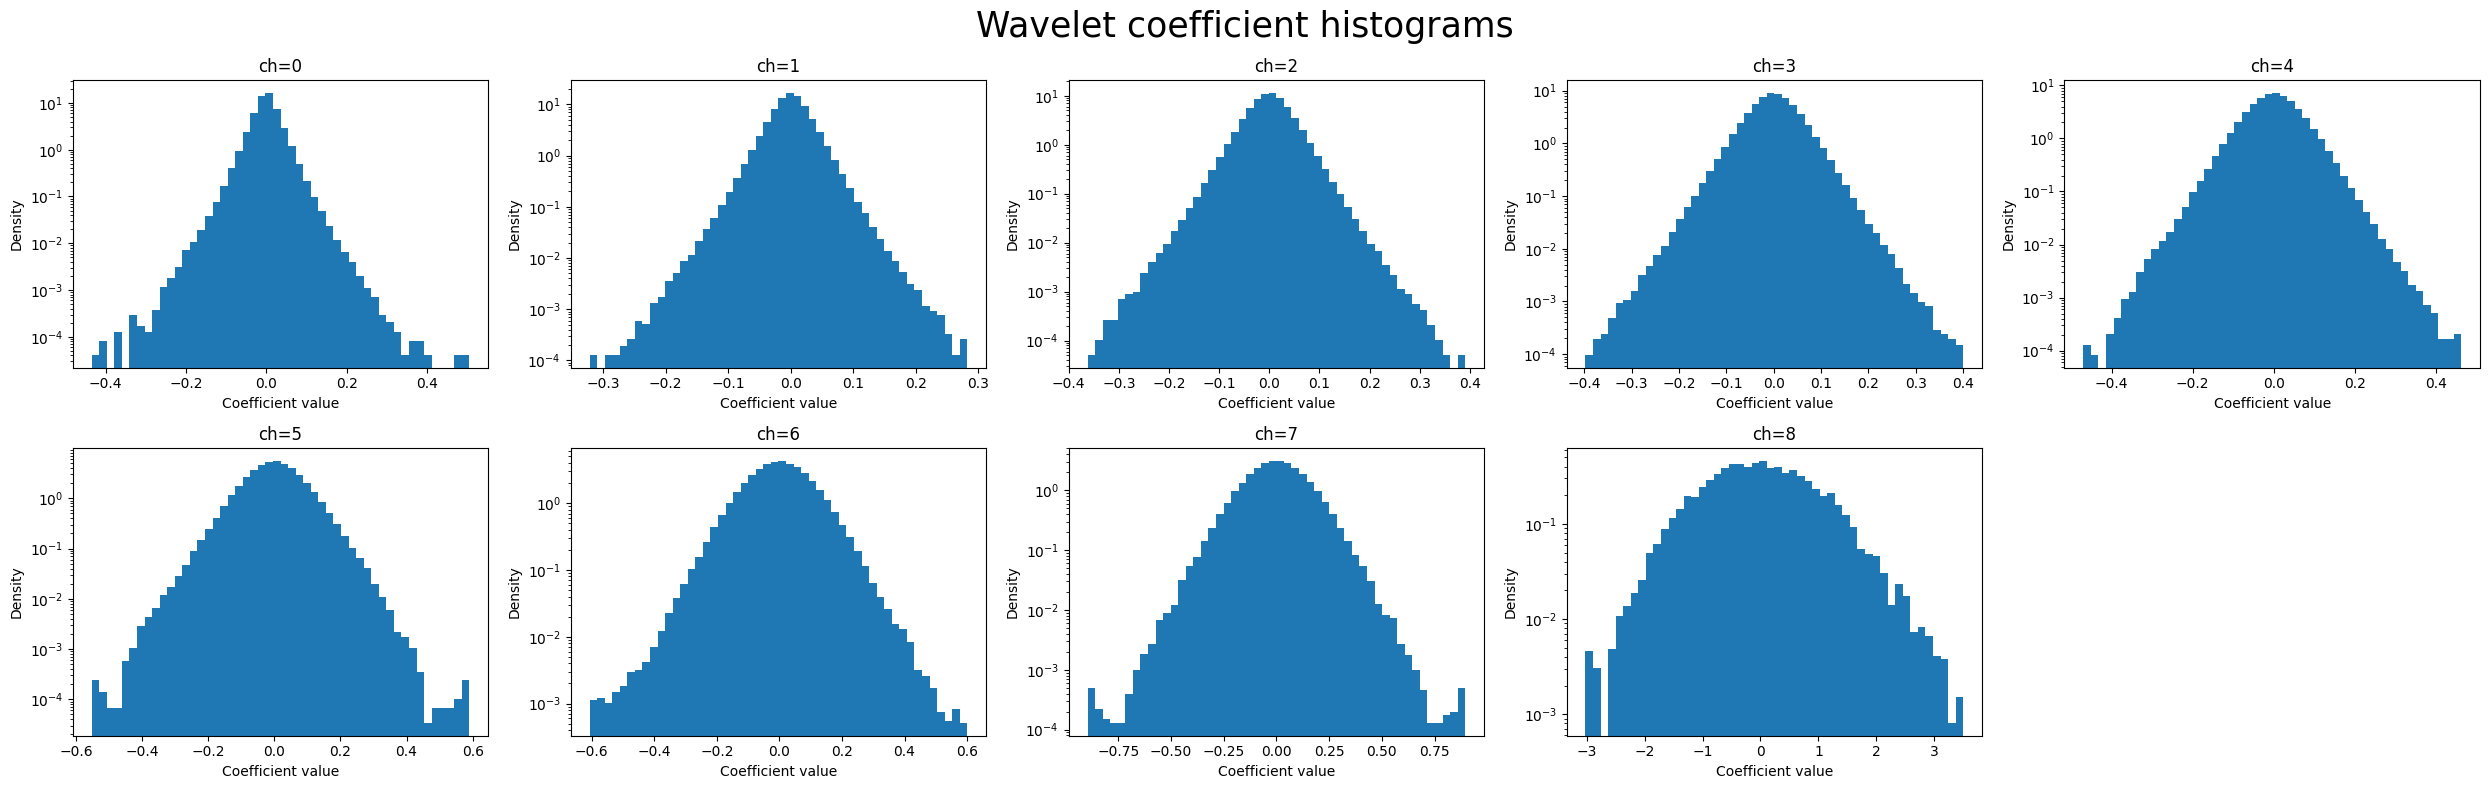

In [13]:
%matplotlib inline 
wt = torch.fft.ifft(torch.fft.fft(x1) * filters).real  # (B, J, T)
print(wt.shape) 
n_wavelets = filters.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=50, density=True, log=True)
    axes[i].set_title(f"ch={i}")
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=25)
plt.tight_layout()
plt.show()

## Wavelet power spectrum 

## Run or load an experiment --> Instead of doing this upload the thetas (MGD and REG) I sent you 

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


In [14]:
# upload thetas instead 
# note that I sent you a database with (r,) thetas per 50 runs (indexed by different seed) 
# you can do the analysis for all runs and average for ex. 
result = run_experiment(args, M, config, x1, filters, t, logger, root, device=device)

2026-07-21 09:45:07  INFO      Loaded existing results for jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_20_terms6d216e41_20260717_0036


## Theta scaling analysis 

In [15]:
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
)
print(potentials) 

{'L_6': L2p_norm(), 'Scattering_First_Order': Scattering_First_Order_1d(), 'Scattering_Second_Order': Scattering_Second_Order_1d(), 'Scattering_Fourth_Order_Mod2_Real_Q1': Scattering_Fourth_Order_Mod2_Real_1d(), 'Scattering_Fourth_Order_Mod2_Imag_Q1': Scattering_Fourth_Order_Mod2_Imag_1d()}


### functions to build dataframe of the scattering potential thetas and do plots 

In [16]:
"""
theta_analysis.py

Analysis utilities for Scattering_Fourth_Order_{Real,Imag,Mod2_Real,Mod2_Imag}
theta coefficients produced by run_experiment().

Harmonized with the current notebook structure:
    result = run_experiment(args, M, config, x1, filters, t, logger, root, device=device)
    potentials = get_1d_potentials(terms, J, filters, Q, scalar_param=None, parallel=False)
There is no `experiments`/`results` dict in the current notebook -- use `result`
and `potentials` directly.

Usage:
    from theta_analysis import build_theta_dataframe, plot_xi_decay, ...

    df, extras = build_theta_dataframe(
        result, potentials, target_key="Scattering_Fourth_Order_Mod2_Real_Q1",
        x1=x1, filters=filters, norm_order=4,
    )
    plot_xi_decay(df)
    plot_theta_vs_b(df)
    plot_theta_vs_a_fixed_b(df, value_col="theta_raw_mean")
    plot_index_structure(df, J=J)
    plot_theta_heatmap(df, value_col="theta_raw_mean")
    plot_theta_grouped_by_j(df)

norm_order: use 2 for Real/Imag potentials (order-2 micro-norm, theta_physical
= theta_fitted * sqrt(E1*E2)); use 4 for Mod2_Real/Mod2_Imag potentials
(theta_physical = theta_fitted * E1*E2).
"""

# ---------------------------------------------------------------------
# 1. Column mapping: potentials dict -> theta_t column slices
# ---------------------------------------------------------------------
def _potential_width(p, key, known_dims=None):
    """(dim, source) for potential p. Never silently assumes dim=1."""
    known_dims = known_dims or {}
    for attr in ('n_theta', 'num_theta', 'theta_dim'):
        if hasattr(p, attr):
            val = getattr(p, attr)
            val = val() if callable(val) else val
            if torch.is_tensor(val):
                val = val.numel()
            return int(val), f"'{attr}'"
    if hasattr(p, 'num_coefficients'):
        return int(p.num_coefficients), "'num_coefficients'"
    if hasattr(p, 'indices'):
        idx = p.indices
        width = idx.shape[-1] if torch.is_tensor(idx) else np.asarray(idx).shape[-1]
        return int(width), "'.indices.shape[-1]'"
    for attr in ('num_regions', 'n_regions'):
        if hasattr(p, attr):
            n_reg = int(getattr(p, attr))
            n_par = int(getattr(p, 'n_params_per_region', 1))
            return n_reg * n_par, f"'{attr}' x n_params_per_region"
    if key in known_dims:
        return int(known_dims[key]), "known_dims override (UNVERIFIED by introspection)"
    raise RuntimeError(f"Cannot determine theta width for '{key}' ({type(p).__name__}).")


def theta_column_map(potentials, theta_t_np, known_dims=None, verbose=True):
    """
    dict: key -> (start, dim) column slice into theta_t, for every potential
    in `potentials` (dict, insertion-order must equal theta_t column order,
    which is how get_1d_potentials + run_experiment build it).
    """
    keys = list(potentials.keys())
    dims, sources = [], []
    for k in keys:
        d, src = _potential_width(potentials[k], k, known_dims)
        dims.append(d)
        sources.append(src)
    offsets = np.cumsum([0] + dims)
    n_theta = theta_t_np.shape[1]
    if sum(dims) != n_theta:
        lines = "\n".join(f"  {k:35s} {d:5d}  {s}" for k, d, s in zip(keys, dims, sources))
        raise AssertionError(f"sum(dims)={sum(dims)} != theta_t.shape[1]={n_theta}\n{lines}")
    if verbose:
        for k, d, o, s in zip(keys, dims, offsets[:-1], sources):
            print(f"{k:35s} {d:5d}  [{o:4d}:{o+d:<4d}]  {s}")
    return {k: (int(o), int(d)) for k, o, d in zip(keys, offsets[:-1], dims)}


# ---------------------------------------------------------------------
# 2. Load thetas for one target potential
# ---------------------------------------------------------------------
def load_theta_for_potential(result, potentials, target_key, known_dims=None, verbose=True):
    """
    Slice theta_t (from `result['theta_t']`) down to the columns of `target_key`.
    Returns (theta_raw: np.ndarray (T, dim), potential, start, dim).
    Handles theta_t on any device / dtype.
    """
    theta_t = result['theta_t']
    theta_t_np = theta_t.detach().cpu().numpy() if torch.is_tensor(theta_t) else np.asarray(theta_t)

    col_map = theta_column_map(potentials, theta_t_np, known_dims, verbose)
    if target_key not in col_map:
        raise KeyError(f"'{target_key}' not in potentials: {list(potentials.keys())}")
    start, dim = col_map[target_key]

    potential = potentials[target_key]
    if hasattr(potential, 'num_coefficients') and hasattr(potential, 'indices'):
        assert dim == potential.num_coefficients == potential.indices.shape[-1], (
            f"dim mismatch: col_map={dim}, num_coefficients={potential.num_coefficients}, "
            f"indices={potential.indices.shape[-1]}"
        )
    theta_raw = theta_t_np[:, start:start + dim]
    if verbose:
        print(f"-> {target_key}: cols [{start}:{start + dim}] out of {theta_t_np.shape[1]}")
    return theta_raw, potential, start, dim


# ---------------------------------------------------------------------
# 3. Decode (j, a, b) indices for a 4th-order potential
# ---------------------------------------------------------------------
def decode_jab(potential, j_row=None, verbose=True):
    """
    potential.indices is (3, n_coeff): one row is the shared first-layer
    scale j, the other two are absolute second-layer scales s1,s2. Detect
    which row is j via the combinatorial fingerprint for offset=1, lite=True,
    no-diag: #pairs at fixed j == C(J-j, 2). Pass j_row explicitly to skip
    detection / override a bad guess.
    Returns j, a, b, s1, s2 (np.ndarray, a=min(s)-j < b=max(s)-j), j_row.
    """
    idx = potential.indices.long().detach().cpu()
    J = potential.J

    if j_row is None:
        expected = {j: math.comb(J - j, 2) for j in range(J)}
        expected = {j: c for j, c in expected.items() if c > 0}
        row_vc = []
        for r in range(3):
            vals = idx[r].numpy()
            uniq, counts = np.unique(vals, return_counts=True)
            row_vc.append(dict(zip(uniq.tolist(), counts.tolist())))
        j_row = next((r for r in range(3) if row_vc[r] == expected), None)
        if j_row is None:
            def mismatch(vc):
                ks = set(vc) | set(expected)
                return sum(abs(vc.get(k, 0) - expected.get(k, 0)) for k in ks)
            scores = [mismatch(vc) for vc in row_vc]
            j_row = int(np.argmin(scores))
            if verbose:
                print(f"WARNING: no exact fingerprint match, best guess j_row={j_row} "
                      f"(mismatch scores {scores}); pass j_row= explicitly if this is wrong.")
        elif verbose:
            print(f"-> detected j_row={j_row} from combinatorial fingerprint.")

    other = [r for r in range(3) if r != j_row]
    j = idx[j_row].numpy()
    s1_raw, s2_raw = idx[other[0]].numpy(), idx[other[1]].numpy()
    lo, hi = np.minimum(s1_raw, s2_raw), np.maximum(s1_raw, s2_raw)
    a, b = lo - j, hi - j

    if verbose and not ((a >= 1).all() and (b > a).all()):
        print(f"WARNING: offset/lite assumptions violated: {(a < 1).sum()} entries a<1, "
              f"{(b <= a).sum()} entries b<=a. j_row={j_row} may be wrong -- check manually.")
    return j, a, b, lo, hi, j_row


# ---------------------------------------------------------------------
# 4. Cross-scale normalization theta_fitted -> theta_physical
# ---------------------------------------------------------------------
def compute_norm_jab(x1, filters, s1_arr, s2_arr, order=2):
    """
    norm_jab[i] = (E[|Wx_s1|^2] * E[|Wx_s2|^2]) ** (order/4), Wx_s = single-
    layer wavelet transform of x1 at absolute scale s, using the same J+1-
    channel `filters` bank the potential's second layer uses.
    order=2 -> sqrt(E1*E2)  (Real/Imag potentials, micro-norm on |x|)
    order=4 -> E1*E2        (Mod2 potentials, micro-norm on |x|^2)
    Runs on x1's device; filters moved to match, no_grad, no side effects.
    """
    filters = filters.to(x1.device)
    with torch.no_grad():
        Wx_full = torch.fft.ifft(filters * torch.fft.fft(x1))                    # (B, J+1, T)
        E_scale = (Wx_full.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()   # (J+1,)
    s1_arr, s2_arr = np.asarray(s1_arr), np.asarray(s2_arr)
    return (E_scale[s1_arr] * E_scale[s2_arr]) ** (order / 4)


# ---------------------------------------------------------------------
# 5. Build one tidy DataFrame: index structure + cleaned/normalized theta
# ---------------------------------------------------------------------
def build_theta_dataframe(result, potentials, target_key, x1, filters,
                           norm_order=2, j_row=None,
                           known_dims=None, verbose=True):
    """
    Single entry point. Loads theta columns for `target_key`, decodes
    (j,a,b), drops burn-in + non-finite rows, de-normalizes, and returns:
      df      : one row per (j,a,b) coefficient, columns
                j, a, b, s1, s2, norm_jab, theta_t1, theta_t1_normalized,
                theta_std, cv, reliable
      extras  : dict with theta_scat (per-kept-timestep, physical units),
                keep (bool mask into original T), potential, start, dim, j_row
    """
    theta_raw, potential, start, dim = load_theta_for_potential(
        result, potentials, target_key, known_dims, verbose)
    j_arr, a_arr, b_arr, s1_arr, s2_arr, j_row = decode_jab(potential, j_row, verbose)

    if theta_raw.shape[0] > 1:  # if loadin the whole (T, r) thetas, otherwise it's already the last value
        final_theta = theta_raw[-1,:]
    else: 
        final_theta = theta_raw
    norm_jab = compute_norm_jab(x1, filters, s1_arr, s2_arr, order=norm_order)

    final_theta_normalized = final_theta * norm_jab

    df = pd.DataFrame({
        'j': j_arr, 'a': a_arr, 'b': b_arr, 's1': s1_arr, 's2': s2_arr,
        'norm_jab': norm_jab,
        'theta_t1': final_theta,
        'theta_t1_normalized': final_theta_normalized,
    })
    extras = dict(potential=potential, dim=dim, j_row=j_row)
    return df, extras


# ---------------------------------------------------------------------
# 6. Plotting
# ---------------------------------------------------------------------
def plot_xi_decay(df, value_col='theta_t1'):
    """Fit theta_{j,a,b} ~ exp(-xi_{j,a}*b) per (j,a); plot |xi| vs j."""
    xi = {}
    for (j, a), g in df.groupby(['j', 'a']):
        g = g.sort_values('b')
        vals = g[value_col].abs().values
        bs = g['b'].values
        mask = (vals > 0) & np.isfinite(vals)
        if mask.sum() < 2:
            continue
        slope, _ = np.polyfit(bs[mask], np.log(vals[mask]), 1)
        xi[(j, a)] = -slope

    plt.figure(figsize=(6, 4))
    for a in sorted({a for (_, a) in xi}):
        js = sorted(j for (j, aa) in xi if aa == a)
        xis = [xi[(j, a)] for j in js]
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        plt.plot(js, np.abs(xis), **kw)
    plt.xlabel('scale j'); plt.ylabel(r'$|\xi_{j,a}|$')
    plt.title(r'Decay rate of $\theta_{j,a,b}$ in $b$, vs $j$')
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()
    return xi


def plot_theta_vs_b(df, value_col='theta_t1', signed=False):
    """One subplot per j: theta_{j,a,b} vs b, one line per a."""
    js_unique = sorted(df['j'].unique())
    fig, axes = plt.subplots(1, len(js_unique), figsize=(4 * len(js_unique), 3.5),
                              sharey=True, squeeze=False)
    for ax, j in zip(axes[0], js_unique):
        sub = df[df['j'] == j]
        for a, g in sub.groupby('a'):
            g = g.sort_values('b')
            if signed:
                ax.plot(g['b'], g[value_col].values, 'o-', label=f'a={a}')
            else:
                ax.semilogy(g['b'], g[value_col].abs().values, 'o-', label=f'a={a}')
        if signed:
            ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.set_title(f'j={j}'); ax.set_xlabel('b')
    ylab = r'$\theta_{j,a,b}$' if signed else r'$|\theta_{j,a,b}|$'
    axes[0, 0].set_ylabel(ylab)
    axes[0, 0].legend(fontsize=7)
    plt.tight_layout(); plt.show()


def plot_theta_vs_a_fixed_b(df, value_col='theta_raw_mean'):
    """For each b: theta vs a (scale separation), one line per j."""
    for b, sub in df.groupby('b'):
        plt.figure(figsize=(6, 4))
        for j, g in sub.groupby('j'):
            g = g.sort_values('a')
            plt.plot(g['a'], g[value_col].abs(), 'o-', label=f'j={j}')
        plt.axhline(0, color='k', ls='--', lw=0.8)
        plt.yscale('log')
        plt.xlabel('a (scale separation)'); plt.ylabel(rf'$|{value_col}|$')
        plt.title(f'Coupling vs separation a, fixed b={b}')
        plt.legend(fontsize=7); plt.tight_layout(); plt.show()


def plot_index_structure(df, J):
    """Diagnostic: which (a,b) pairs exist per j (pure index structure)."""
    js_unique = sorted(df['j'].unique())
    fig, axes = plt.subplots(1, len(js_unique), figsize=(2.6 * len(js_unique), 3),
                              sharex=True, sharey=True, squeeze=False)
    for ax, j in zip(axes[0], js_unique):
        sub = df[df['j'] == j]
        ax.scatter(sub['a'], sub['b'], s=30)
        ax.plot([0, J], [0, J], 'k--', lw=0.6)
        ax.set_title(f'j={j}  (n={len(sub)})'); ax.set_xlabel('a')
    axes[0, 0].set_ylabel('b')
    plt.suptitle('Which (a,b) pairs exist per j  (s1=j+a, s2=j+b, both <= J)')
    plt.tight_layout(); plt.show()


def plot_theta_heatmap(df, value_col='theta_raw_mean'):
    """Per-a heatmap of |theta| over (j,b)."""
    max_j = int(df['j'].max()) + 1
    max_b = int(df['b'].max()) + 1
    unique_a = sorted(df['a'].unique())
    fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)
    for idx, a in enumerate(unique_a):
        grid = np.full((max_j, max_b), np.nan)
        sub = df[df['a'] == a]
        for _, row in sub.iterrows():
            j, b, v = int(row['j']), int(row['b']), abs(row[value_col])
            if np.isfinite(v):
                grid[j, b] = v
        ax = axes[0, idx]
        if not (np.isfinite(grid).any() and np.nanmax(grid) > 0):
            ax.set_title(f'Offset a = {a} (no valid data)')
            continue
        im = ax.imshow(grid, origin='lower', cmap='viridis',
                        norm=LogNorm(vmin=np.nanmin(grid[grid > 0]), vmax=np.nanmax(grid)),
                        aspect='auto')
        ax.set_title(f'Offset a = {a}'); ax.set_xlabel('Relative Scale b')
        if idx == 0:
            ax.set_ylabel('First-layer Scale j')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(rf'Coupling Magnitude Topology $|{value_col}|$', y=1.02)
    plt.tight_layout(); plt.show()


def plot_theta_grouped_by_j(df, value_col='theta_t1'):
    """Mean_b |theta| vs j, one line per a, + overall mean across a."""
    df = df.copy()
    df['abs_theta'] = df[value_col].abs()
    mean_over_b = df.groupby(['j', 'a'])['abs_theta'].mean().unstack('a')
    plt.figure(figsize=(6, 4))
    for a in mean_over_b.columns:
        plt.semilogy(mean_over_b.index, mean_over_b[a], 'o-', label=f'a={a}')
    plt.semilogy(mean_over_b.index, mean_over_b.mean(axis=1), 'ko-', lw=2.5, label='overall mean')
    plt.xlabel('scale j'); plt.ylabel(r'mean$_b\,|\theta|$')
    plt.legend(fontsize=7); plt.tight_layout(); plt.show()

In [17]:
df, extras = build_theta_dataframe(
    result, potentials, target_key="Scattering_Fourth_Order_Mod2_Real_Q1",
    x1=x1, filters=filters, norm_order=4,
)
# plot_xi_decay(df)
# plot_theta_vs_b(df)
# plot_theta_vs_a_fixed_b(df, value_col="theta_t1")
# plot_index_structure(df, J=J)
# plot_theta_heatmap(df, value_col="theta_t1")
# plot_theta_grouped_by_j(df)

L_6                                     9  [   0:9   ]  'num_coefficients'
Scattering_First_Order                  8  [   9:17  ]  'num_coefficients'
Scattering_Second_Order                 9  [  17:26  ]  'num_coefficients'
Scattering_Fourth_Order_Mod2_Real_Q1    84  [  26:110 ]  'num_coefficients'
Scattering_Fourth_Order_Mod2_Imag_Q1    56  [ 110:166 ]  'num_coefficients'
-> Scattering_Fourth_Order_Mod2_Real_Q1: cols [26:110] out of 166
-> detected j_row=0 from combinatorial fingerprint.


## Theta trajectories 

In [ ]:
# Move to CPU and convert to numpy for easier plotting
import matplotlib.pyplot as plt
theta_t = theta_t.cpu()
theta_reg_t = theta_reg_t.cpu()

# Get the number of time steps (rows) for each
len_t = theta_t.shape[0]
len_reg = theta_reg_t.shape[0]
print(len_t, len_reg) 

# Iterate through each feature/column
for i in range(theta_t.shape[1]): 
    # Create matching X-axes spanning from 0 to 1 (or 0 to len_t if preferred)
    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    plt.figure(figsize=(10, 4))
    
    # Plot both on the same axes
    #plt.plot(result['xt'], theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    
    plt.title(f"Experiment {label} - Feature {i} Superimposed")
    plt.xlabel("Normalized Time / Progress")
    plt.ylabel("Value")
    plt.legend()
    plt.show()  # Show the combined plot